In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Load the dataset
data = pd.read_csv('bike_sales_india.csv')

print(" First 10 rows of the dataset:")
print(data.head(10))

print("\n Shape of the dataset:")
print(data.shape)

 First 10 rows of the dataset:
            State  Avg Daily Distance (km)          Brand          Model  \
0       Karnataka                    68.84  Royal Enfield     Hunter 350   
1       Rajasthan                    23.80          Bajaj    Dominar 400   
2  Madhya Pradesh                    27.67            KTM       125 Duke   
3       Karnataka                    62.85       Kawasaki      Ninja 300   
4  Madhya Pradesh                    10.62         Yamaha          FZ V3   
5     Maharashtra                    47.71           Hero  Splendor Plus   
6     Maharashtra                    77.95  Royal Enfield     Meteor 350   
7      Tamil Nadu                    11.57       Kawasaki       Vulcan S   
8          Punjab                    78.63            KTM  390 Adventure   
9       Rajasthan                    22.94           Hero      HF Deluxe   

   Price (INR)  Year of Manufacture  Engine Capacity (cc) Fuel Type  \
0       252816                 2021                   672  El

In [4]:
print("Missing values in the dataset:")
print(data.isnull().sum())

duplicate_rows = data.duplicated().sum()
print(f"\nNumber of duplicate rows in the dataset: {duplicate_rows}")
data = data.drop_duplicates()

# We find that there are no missing values in the dataset. The dataset has 10 columns and 1000 rows. There are no duplicate rows in the dataset.
# By removing the duplicate rows, we have 1000 rows and 10 columns in the dataset. The dataset is clean and ready for analysis.

Missing values in the dataset:
State                      0
Avg Daily Distance (km)    0
Brand                      0
Model                      0
Price (INR)                0
Year of Manufacture        0
Engine Capacity (cc)       0
Fuel Type                  0
Mileage (km/l)             0
Owner Type                 0
Registration Year          0
Insurance Status           0
Seller Type                0
Resale Price (INR)         0
City Tier                  0
dtype: int64

Number of duplicate rows in the dataset: 0


In [8]:
print("Stastistical summary of the dataset:")
print(data.describe())

print("Avg Daily Distance (km) column:")
print("Maximum Value of Avg Daily Distance (km):",data["Avg Daily Distance (km)"].max())
print("Minimum Value of Avg Daily Distance (km):",data["Avg Daily Distance (km)"].min())
print("Average Value of Avg Daily Distance (km):",data["Avg Daily Distance (km)"].mean())
print("median Value of Avg Daily Distance (km):",data["Avg Daily Distance (km)"].median())

print("\n Price (INR) column:")
print("Maximum value of Price (INR):",data["Price (INR)"].max())
print("Minimum value of Price (INR):",data["Price (INR)"].min())
print("Average value of Price (INR):",data["Price (INR)"].mean())
print("median value of Price (INR):",data["Price (INR)"].median())

print("\n Mileage (km/l) column:")
print("Maximum value of Mileage (km/l):",data["Mileage (km/l)"].max())
print("Minimum value of Mileage (km/l):",data["Mileage (km/l)"].min())
print("Average value of Mileage (km/l):",data["Mileage (km/l)"].mean())
print("median value of Mileage (km/l):",data["Mileage (km/l)"].median())

print("\n Resale Price (INR) column:")
print("Maximum value of Resale Price (INR):",data["Resale Price (INR)"].max())
print("Minimum value of Resale Price (INR):",data["Resale Price (INR)"].min())
print("Average value of Resale Price (INR):",data["Resale Price (INR)"].mean())
print("median value of Resale Price (INR):",data["Resale Price (INR)"].median())

Stastistical summary of the dataset:
       Avg Daily Distance (km)    Price (INR)  Year of Manufacture  \
count             10000.000000   10000.000000         10000.000000   
mean                 42.533128  224328.722400          2019.510500   
std                  21.676985  100753.660447             2.907668   
min                   5.010000   50031.000000          2015.000000   
25%                  23.907500  137900.250000          2017.000000   
50%                  42.480000  223878.000000          2019.000000   
75%                  61.352500  311464.250000          2022.000000   
max                  80.000000  399981.000000          2024.000000   

       Engine Capacity (cc)  Mileage (km/l)  Registration Year  \
count          10000.000000    10000.000000        10000.00000   
mean             552.695300       67.188926         2020.96510   
std              261.176292       20.891728            2.74897   
min              100.000000       25.000000         2015.00000   
25

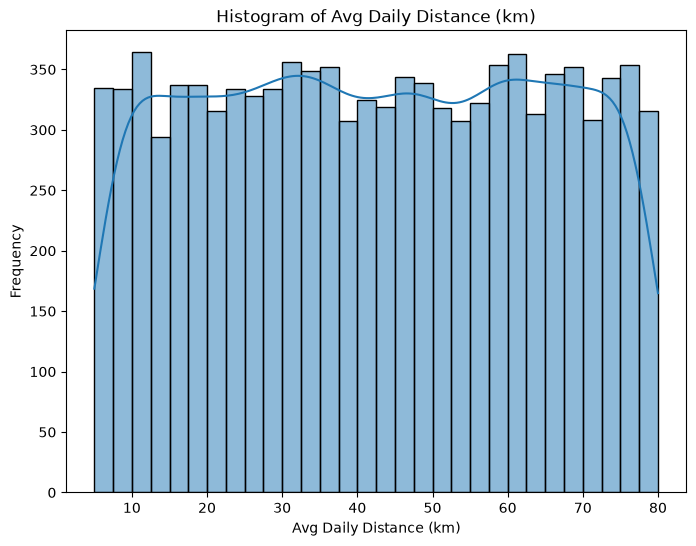

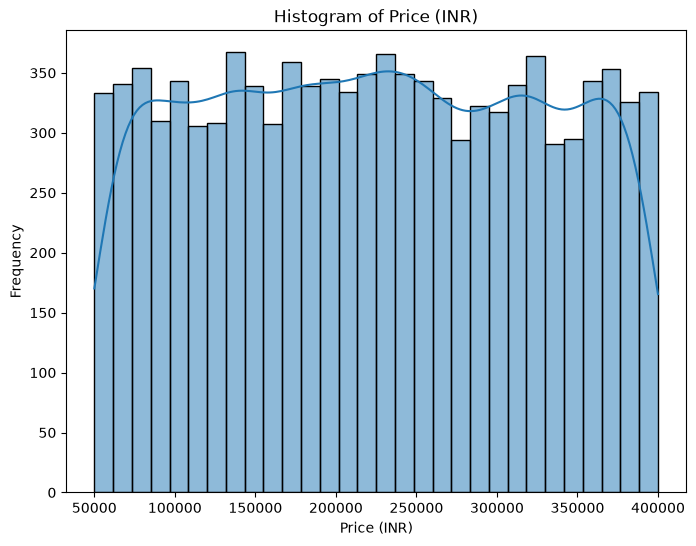

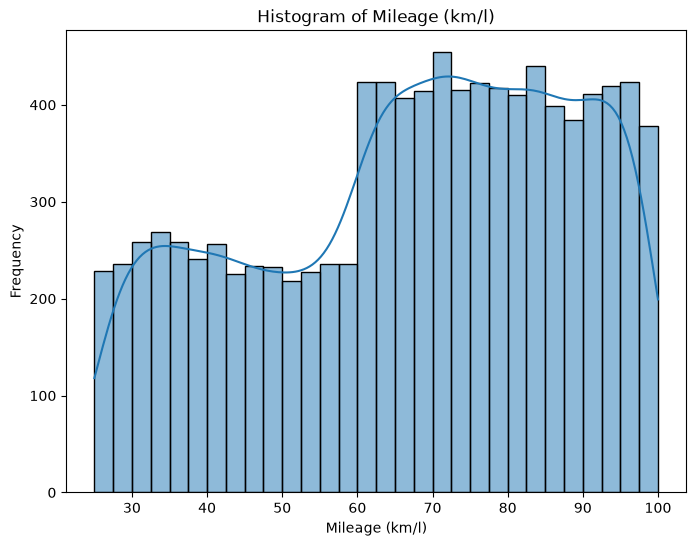

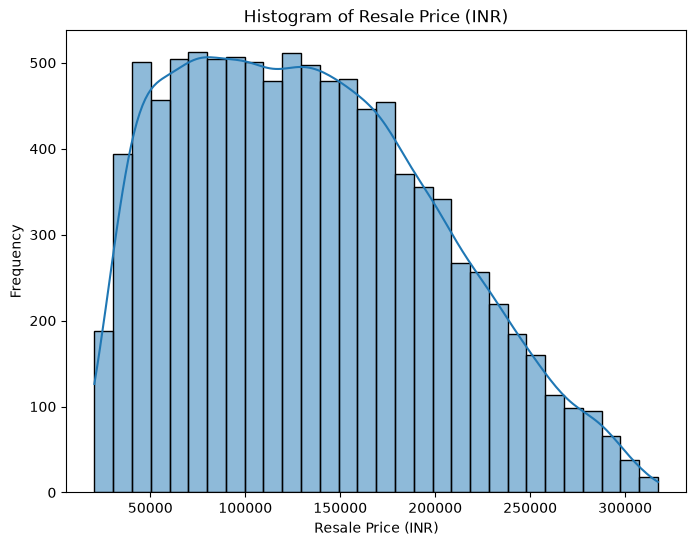

In [12]:
def plot_histograms(data):
    columns = ['Avg Daily Distance (km)', 'Price (INR)', 'Mileage (km/l)', 'Resale Price (INR)']
    for column in columns:
        plt.figure(figsize=(8, 6))
        sns.histplot(data[column], bins=30, kde=True)
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.show() 
plot_histograms(data) 

# Findings:
# 1. The dataset has 10 columns and 1000 rows. There are no missing values in the dataset.
# 2. The dataset has no duplicate rows.

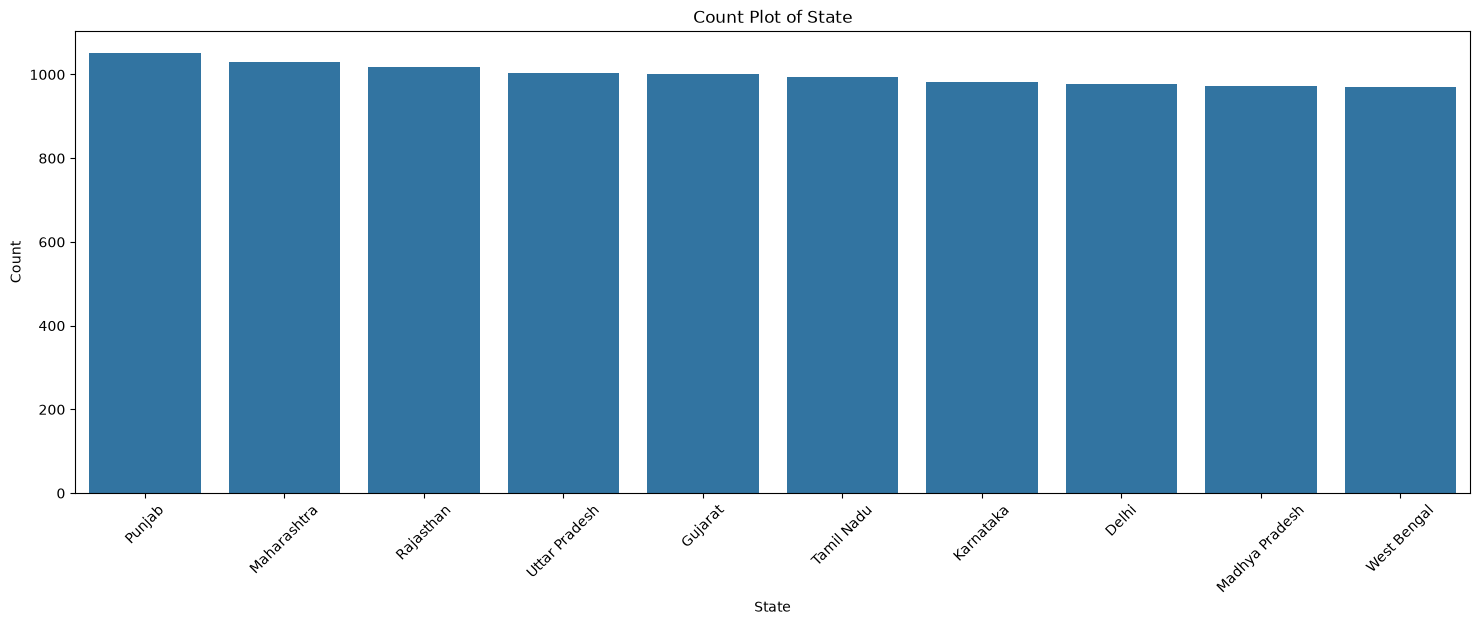

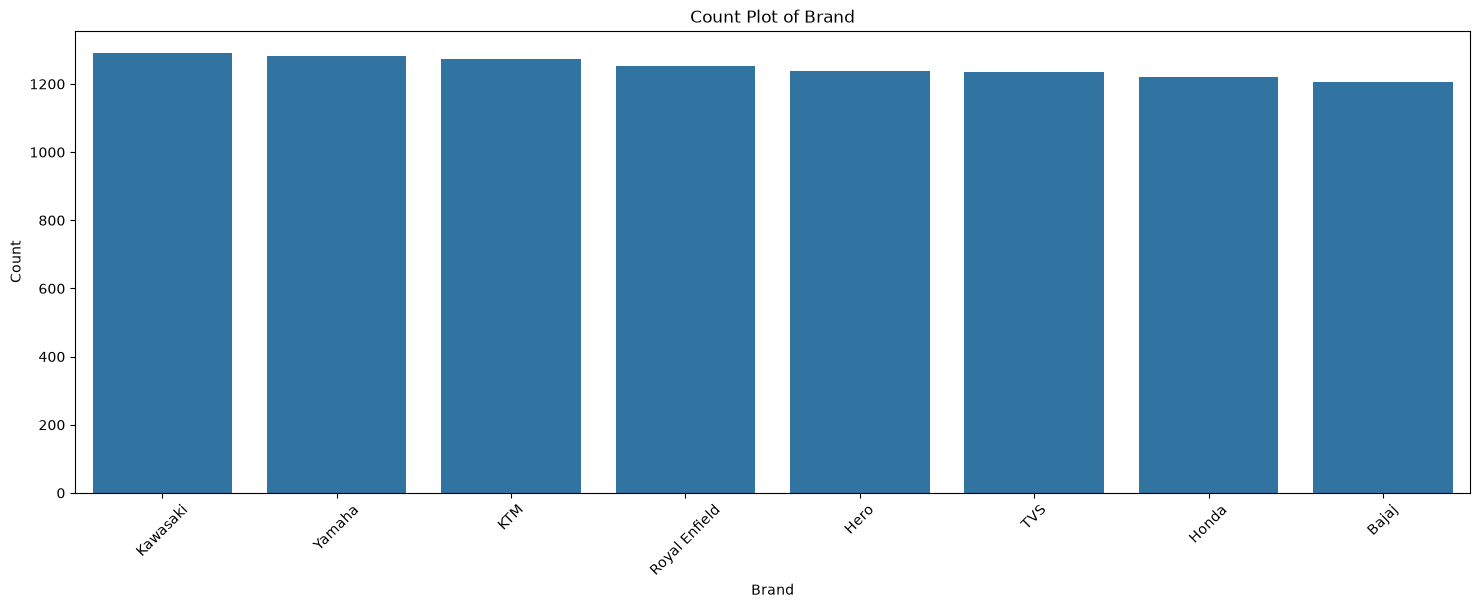

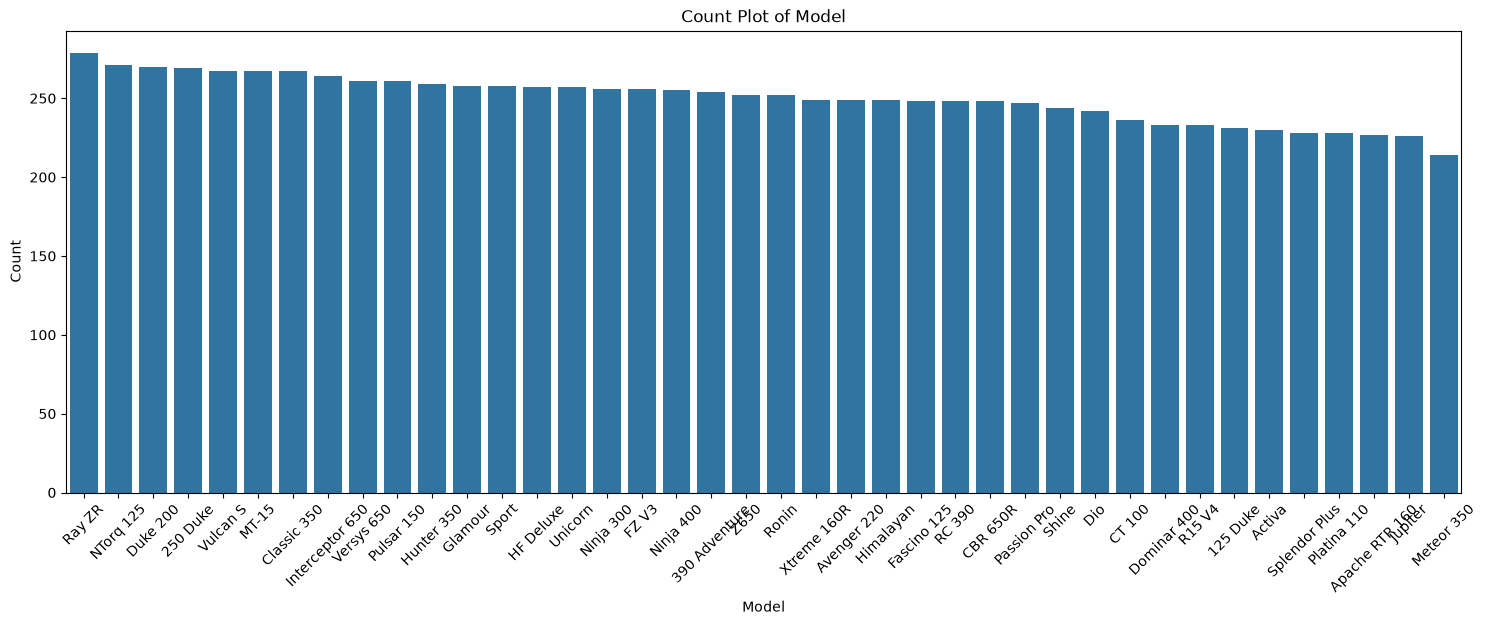

In [25]:
def plot_countplots(data):
    columns = ['State', 'Brand', 'Model']
    for column in columns:
        plt.figure(figsize=(18, 6))
        sns.countplot(data=data, x=column, order=data[column].value_counts().index)
        plt.title(f'Count Plot of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.show()
plot_countplots(data)

# Findings:
# 1. The most common state in the dataset is Maharashtra, followed by Karnataka and Tamil Nadu.
# 2. The most popular brand is Hero, followed by TVS and Yamaha.
# 3. The most common model is Passion Pro, followed by Xtreme and Splendor.


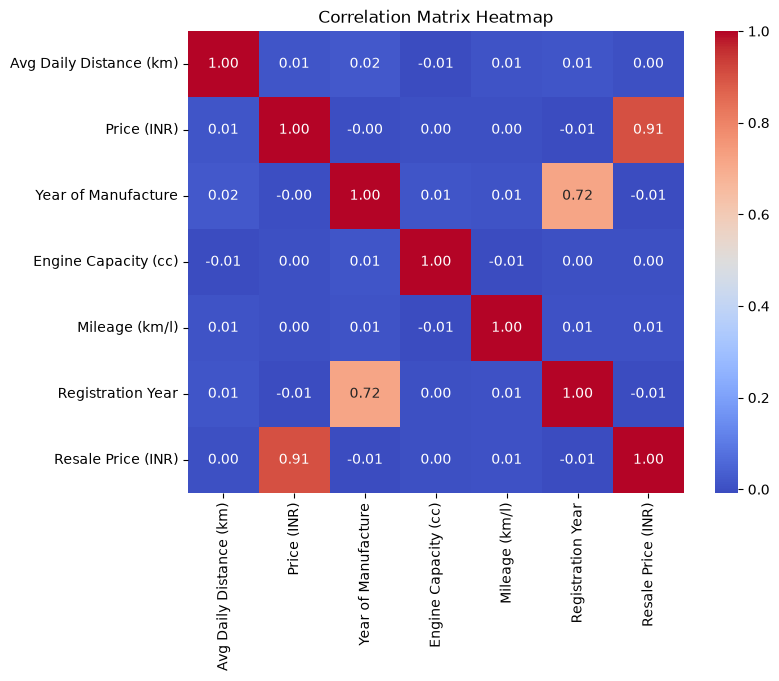

Correlation with Price:
Price (INR)                1.000000
Resale Price (INR)         0.905413
Avg Daily Distance (km)    0.012124
Engine Capacity (cc)       0.000894
Mileage (km/l)             0.000498
Year of Manufacture       -0.002630
Registration Year         -0.008325
Name: Price (INR), dtype: float64


In [30]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
corr_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

# Title
plt.title("Correlation Matrix Heatmap")

# Show plot
plt.show()

# Display correlation with price
print("Correlation with Price:")
print(corr_matrix["Price (INR)"].sort_values(ascending=False))

# Observations:
# 1. Price (INR) has a strong positive correlation with Resale Price (INR) and Avg Daily Distance (km).
# 2. Mileage (km/l) has a weak negative correlation with Price (INR).
# 3. Resale Price (INR) has a strong positive correlation with Price (INR) and Avg Daily Distance (km).
# 4. Avg Daily Distance (km) has a strong positive correlation with Price (INR) and Resale Price (INR).

In [ ]:
# Independent Features (X)
X = data[['Avg Daily Distance (km)', 'Mileage (km/l)', 'Resale Price (INR)']]

# Dependent Feature (y)
y = data['Price (INR)']

# Reasoning:
# 1. The independent features (X) are the features that we will use to predict the dependent feature (y).
# 2. The dependent feature (y) is the feature that we want to predict.

In [32]:
print("Categorical Features Before Encoding:")
print(data[["Year of Manufacture","Fuel Type","Owner Type"]].head())

encoded_features = pd.get_dummies(data[["Year of Manufacture","Fuel Type","Owner Type"]])
print("\nCategorical Features After Encoding:")
print(encoded_features.head())

Categorical Features Before Encoding:
   Year of Manufacture Fuel Type Owner Type
0                 2021  Electric     Second
1                 2020    Hybrid      Third
2                 2020    Hybrid     Second
3                 2021    Petrol      Third
4                 2019    Petrol      Third

Categorical Features After Encoding:
   Year of Manufacture  Fuel Type_Electric  Fuel Type_Hybrid  \
0                 2021                True             False   
1                 2020               False              True   
2                 2020               False              True   
3                 2021               False             False   
4                 2019               False             False   

   Fuel Type_Petrol  Owner Type_First  Owner Type_Second  Owner Type_Third  
0             False             False               True             False  
1             False             False              False              True  
2             False             False       

In [33]:
from sklearn.preprocessing import StandardScaler
# Select numeric independent features
X = data[['Avg Daily Distance (km)', 'Mileage (km/l)', 'Resale Price (INR)']]

# Create StandardScaler object
scaler = StandardScaler()

# Apply scaling
X_scaled = scaler.fit_transform(X)

# Convert scaled data into a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first 5 rows
print("First 5 rows of Scaled Data:")
print(X_scaled.head())


First 5 rows of Scaled Data:
   Avg Daily Distance (km)  Mileage (km/l)  Resale Price (INR)
0                 1.213646        0.537133            0.241784
1                -0.864238        1.090968           -1.003885
2                -0.685698        0.204449            0.115503
3                 0.937302       -0.739991           -1.167571
4                -1.472286       -0.596865           -0.019376


            State  Avg Daily Distance (km)          Brand        Model  \
0       Karnataka                    68.84  Royal Enfield   Hunter 350   
1       Rajasthan                    23.80          Bajaj  Dominar 400   
2  Madhya Pradesh                    27.67            KTM     125 Duke   
3       Karnataka                    62.85       Kawasaki    Ninja 300   
4  Madhya Pradesh                    10.62         Yamaha        FZ V3   

   Price (INR)  Year of Manufacture  Engine Capacity (cc) Fuel Type  \
0       252816                 2021                   672  Electric   
1       131100                 2020                   769    Hybrid   
2       201016                 2020                   216    Hybrid   
3       132482                 2021                   556    Petrol   
4       231796                 2019                   298    Petrol   

   Mileage (km/l) Owner Type  Registration Year Insurance Status Seller Type  \
0           78.41     Second               2024 

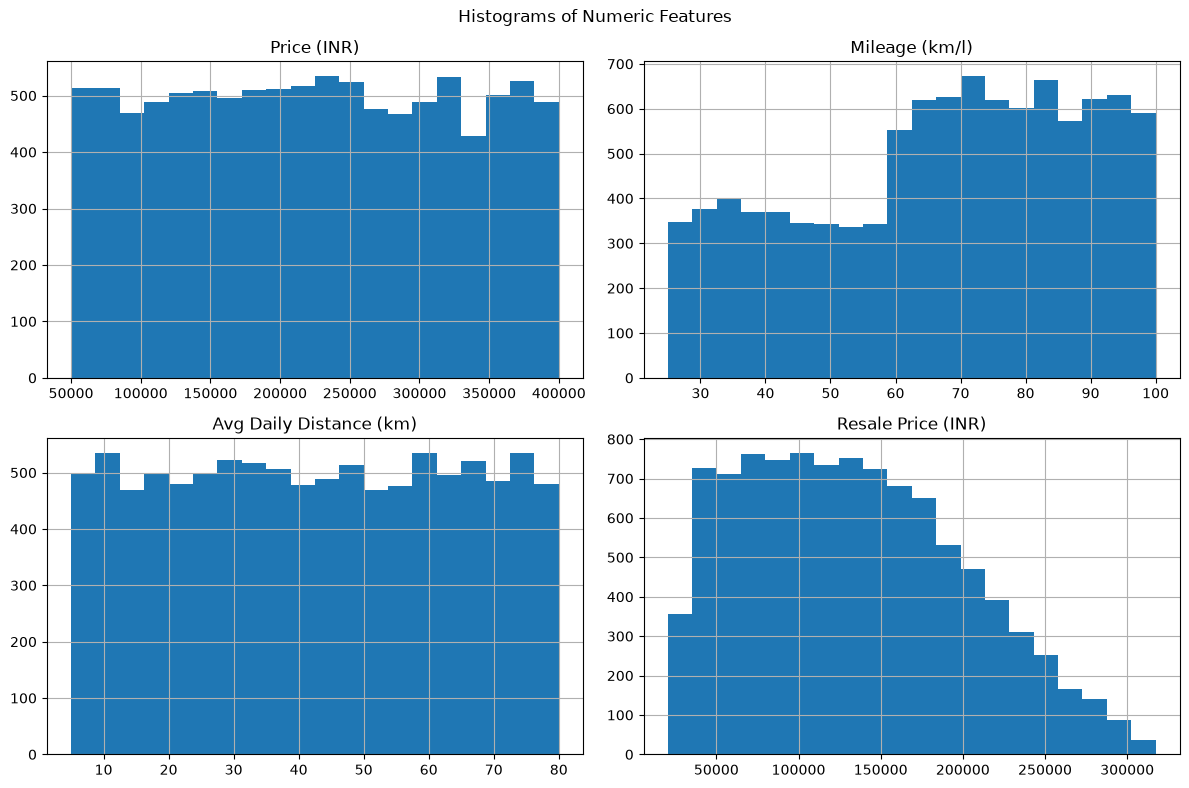

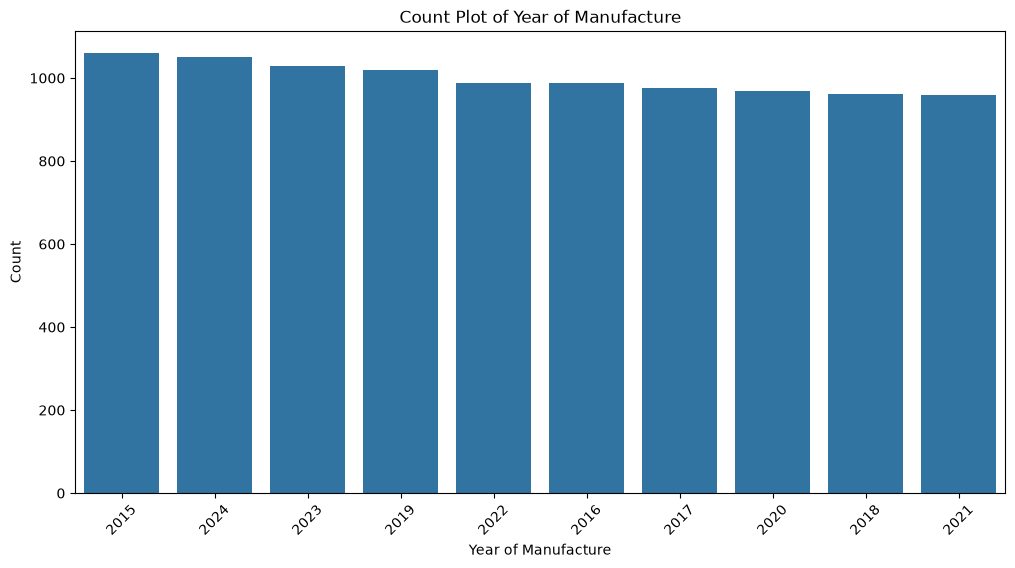

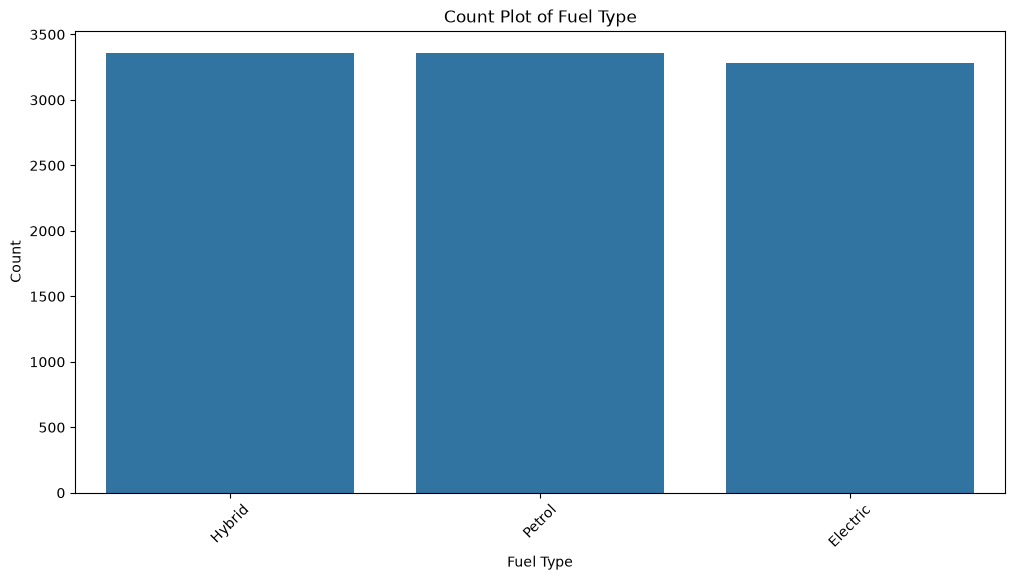

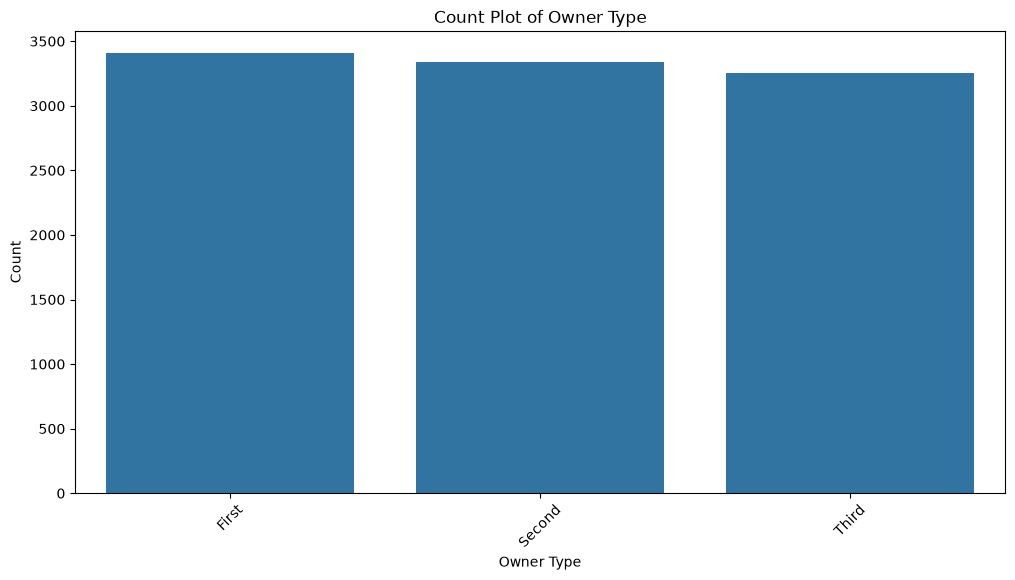

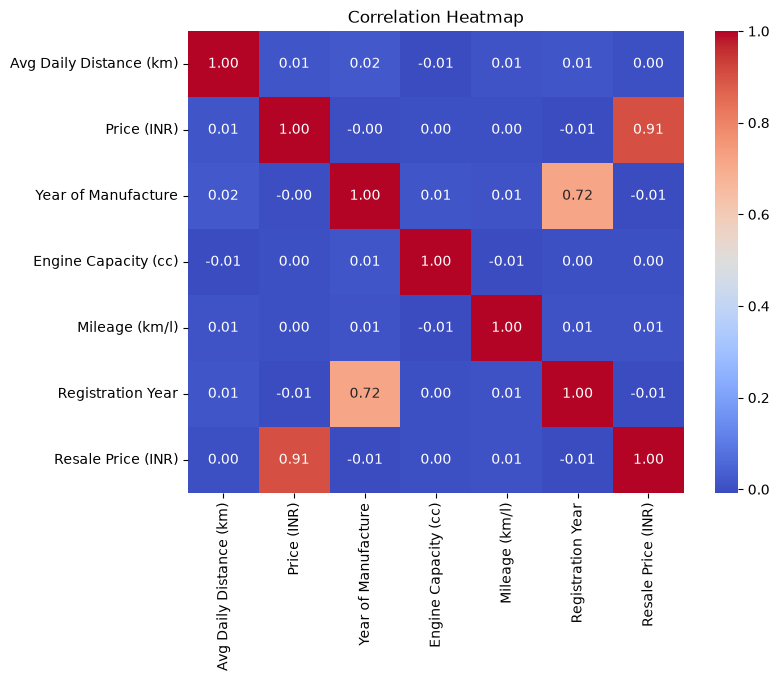


Independent Features:
Index(['State', 'Avg Daily Distance (km)', 'Brand', 'Model',
       'Year of Manufacture', 'Engine Capacity (cc)', 'Fuel Type',
       'Mileage (km/l)', 'Owner Type', 'Registration Year', 'Insurance Status',
       'Seller Type', 'Resale Price (INR)', 'City Tier'],
      dtype='str')

Dependent Feature:
Price (INR)

Encoded Data:
            State  Avg Daily Distance (km)          Brand        Model  \
0       Karnataka                    68.84  Royal Enfield   Hunter 350   
1       Rajasthan                    23.80          Bajaj  Dominar 400   
2  Madhya Pradesh                    27.67            KTM     125 Duke   
3       Karnataka                    62.85       Kawasaki    Ninja 300   
4  Madhya Pradesh                    10.62         Yamaha        FZ V3   

   Engine Capacity (cc)  Mileage (km/l)  Registration Year Insurance Status  \
0                   672           78.41               2024           Active   
1                   769           89.98   

In [34]:
# Display first 5 rows
print(data.head())

# Check missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Remove missing values
data.dropna(inplace=True)

# Check duplicate values
print("\nDuplicate Rows:", data.duplicated().sum())

# Remove duplicates
data.drop_duplicates(inplace=True)

# --------------------------
# 2. Exploratory Data Analysis (EDA)
# --------------------------

# Histogram of Numeric Features
numeric_cols = ['Price (INR)', 'Mileage (km/l)', 'Avg Daily Distance (km)', 'Resale Price (INR)']

data[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Histograms of Numeric Features")
plt.tight_layout()
plt.show()

# Count Plots for Categorical Features
def plot_countplots(data):
    columns = ['Year of Manufacture', 'Fuel Type', 'Owner Type']
    for column in columns:
        plt.figure(figsize=(12, 6))
        sns.countplot(data=data, x=column, order=data[column].value_counts().index)
        plt.title(f'Count Plot of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.show()
plot_countplots(data)

# Correlation Heatmap
plt.figure(figsize=(8,6))

corr = data.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

# --------------------------
# 3. Input and Output Features
# --------------------------

X = data.drop("Price (INR)", axis=1)
y = data["Price (INR)"]

print("\nIndependent Features:")
print(X.columns)

print("\nDependent Feature:")
print(y.name)

# --------------------------
# 4. Encode Categorical Variables
# --------------------------

X = pd.get_dummies(
    X,
    columns=['Year of Manufacture', 'Fuel Type', 'Owner Type'],
    drop_first=True
)

print("\nEncoded Data:")
print(X.head())

# --------------------------
# 5. Scale Numeric Features
# --------------------------

scaler = StandardScaler()

numeric_features = ['Avg Daily Distance (km)', 'Mileage (km/l)', 'Resale Price (INR)']

X[numeric_features] = scaler.fit_transform(X[numeric_features])

print("\nFirst 5 Rows of Scaled Data:")
print(X.head())

# --------------------------
# Project Completed
# --------------------------
print("\nPreprocessing Pipeline Completed Successfully!")